# Evaluating the emulator

This short notebook wil compare the emulator from earlier in part 2 to our model we trained in python in part 1

In [1]:
import os, shutil, json

#Third parties
import numpy as np
import tensorflow as tf
from qkeras.utils import load_qmodel
from sklearn.metrics import roc_curve, auc,precision_recall_curve, confusion_matrix, accuracy_score
import hls4ml
import uproot
import glob

#Plotting
import matplotlib.pyplot as plt

2026-06-22 10:48:24.456520: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-22 10:48:24.459481: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-22 10:48:24.492357: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-22 10:48:24.492396: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-22 10:48:24.492431: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'


/home/antsruin/L1_Trigger/tagger_env/lib/python3.11/site-packages/hls4ml/converters/__init__.py:29: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [2]:
def rms(array):
   return np.sqrt(np.mean(array ** 2))


# Load Model

Load our model from part 1, this can be changed to point at your model

In [3]:

model = load_qmodel('./output2/gnn_tagger_v3/model/saved_model.keras')
model_baseline = load_qmodel('./Analysis/baseline.h5')

2026-06-22 10:48:27.645862: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-22 10:48:27.646208: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/antsruin/L1_Trigger/tagger_env/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [4]:
print("hls4ml layer names:")
for layer in model.layers:
    print(f"  {layer.name}: {layer.name}")

hls4ml layer names:
  model_input: model_input
  bn_input: bn_input
  adj_input: adj_input
  gcn_dense_0: gcn_dense_0
  gcn_agg_0: gcn_agg_0
  gcn_act_0: gcn_act_0
  gcn_dense_1: gcn_dense_1
  gcn_agg_1: gcn_agg_1
  gcn_act_1: gcn_act_1
  pool: pool
  dense_0: dense_0
  act_0: act_0
  jet_pt_reg_0: jet_pt_reg_0
  jet_id_classification: jet_id_classification
  jet_pt_reg_act_0: jet_pt_reg_act_0
  jet_id_output: jet_id_output
  pT_output: pT_output


# Load Data

Load our data from the emulator in part 2, by default it will create a file ```jetTuple_extended_5.root``` in ```CMSSW_15_1_0_pre1/src/FastPUPPI/NtupleMaker/python```

In [5]:
with uproot.open('./Analysis/jetTuple_extended_5.root') as f:
    # Check what tree is available
    print(f.keys())
    tree = f['outnano/Jets']   # typical JetNTuplizer tree path — adjust if different
    
    # Load the SC4NG scores from CMSSW emulation
    cmssw_branches = tree.keys()
    print(cmssw_branches)   # find exact branch names first

['outnano;1', 'outnano/Jets;1']
['event', 'ngenH', 'genH_pt', 'genH_mass', 'genHH_pt', 'genHH_mass', 'jet_eta', 'jet_eta_phys', 'jet_phi', 'jet_phi_phys', 'jet_pt', 'jet_pt_phys', 'jet_pt_raw', 'jet_mass', 'jet_energy', 'jet_SC4NGJet_score_b', 'jet_SC4NGJet_score_light', 'jet_SC4NGJet_score_gluon', 'jet_SC4NGJet_score_charm', 'jet_SC4NGJet_score_taup', 'jet_SC4NGJet_score_taum', 'jet_SC4NGJet_score_muon', 'jet_SC4NGJet_score_electron', 'jet_SC4NGJet_score_regression', 'jet_bjetscore', 'jet_tauscore', 'jet_eletkiso', 'jet_elepfiso', 'jet_elepuppiiso', 'jet_muoniso', 'jet_taupt', 'jet_taueta', 'jet_reject', 'jet_tauflav', 'jet_muflav', 'jet_elflav', 'jet_taudecaymode', 'jet_lepflav', 'jet_taucharge', 'jet_genmatch_lep_pt', 'jet_genmatch_lep_vis_pt', 'jet_genmatch_lep_dR', 'jet_genmatch_pt', 'jet_genmatch_eta', 'jet_genmatch_phi', 'jet_genmatch_mass', 'jet_genmatch_dR', 'jet_taumatch_dR', 'jet_elematch_dR', 'jet_muonmatch_dR', 'jet_genmatch_hflav', 'jet_genmatch_pflav', 'jet_jecmatch_dR',

In [6]:
!source ./setup.sh

In [7]:
!pwd

/home/antsruin/L1_Trigger/TrainTagger


In [8]:
from tagger.data.tools import make_data
from tagger.data.tools import load_data, to_ML, build_adj_matrix

In [9]:
# make_data(infile='./Analysis/jetTuple_extended_5.root', outdir="./Analysis/emulation_data_1/", extras='extra_emulation_fields', tree="outnano/Jets")

# !python /home/antsruin/L1_Trigger/TrainTagger/tagger/data/make_data.py -i ./Analysis/jetTuple_extended_5.root 

In [10]:
load_data_dir= './Analysis/emulation_data_1/'
data, _, class_labels, input_vars, extra_vars = load_data(load_data_dir, percentage=100,test_ratio=0.0)
X_test, Y_test, pt_target, truth_pt, _ = to_ML(data, class_labels) #Last thing was reconstructed pt
ADJ_test  = build_adj_matrix(X_test, input_vars, knn=5)

labels = list(class_labels.keys())
print(X_test.shape)

Loading data from:  ./Analysis/emulation_data_1/
Loading percentage:  100
With test ratio of:  0.0
DEBUG - Checking real_cands in jet sample 5: 10
DEBUG - Checking deta_all shape: (1175, 16)
DEBUG - Checking dphi_all shape: (1175, 16)
DEBUG - Checking deta_all sample: [  2.   0.   0.  -1.   2.   0.   0.   0. -55.  25.   0.   0.   0.   0.
   0.   0.]
DEBUG - Checking dphi_all sample: [  0.   1.  -2.  -5.  -9.  12.  11. -13. -12.  56.   0.   0.   0.   0.
   0.   0.]
DEBUG - Checking deta_all sample: [ 0.02  0.    0.   -0.01  0.02  0.    0.    0.   -0.55  0.25  0.    0.
  0.    0.    0.    0.  ]
DEBUG - Checking dphi_all sample: [ 0.          0.00436332 -0.00872665 -0.02181662 -0.03926991  0.05235988
  0.04799655 -0.0567232  -0.05235988  0.2443461   0.          0.
  0.          0.          0.          0.        ]
DEBUG - Checking dR_i sample: [[0.         0.02047043 0.02182094 0.03709407 0.03926992 0.05604954
  0.05199679 0.06014576 0.5723998  0.33556673]
 [0.02047043 0.         0.0130899

In [11]:
testing_dir = './output2/gnn_tagger_v3/testing_data/'

X_test_old      = np.load(testing_dir + 'X_test.npy')
ADJ_test_old    = np.load(testing_dir + 'ADJ_test.npy')
Y_test_old      = np.load(testing_dir + 'y_test.npy')
pt_target_test_old  = np.load(testing_dir + 'pt_target_test.npy')
truth_pt_old    = np.load(testing_dir + 'truth_pt_test.npy')
reco_pt_old     = np.load(testing_dir + 'reco_pt_test.npy')

In [12]:
print(X_test.shape,ADJ_test.shape)
print(X_test_old.shape, ADJ_test_old.shape)
print(Y_test_old.shape, Y_test_old[0])
print("Class labels:", labels)

(1175, 16, 20) (1175, 16, 16)
(19230, 16, 20) (19230, 16, 16)
(19230, 8) [0. 0. 0. 0. 0. 1. 0. 0.]
Class labels: ['b', 'charm', 'light', 'gluon', 'taup', 'taum', 'muon', 'electron']


# Convert the model

This function runs the conversion to hls, to match the emulator this conversion needs to be the same as part 1 with the correct precisions

In [13]:
def convert(model ,outdir = './Analysis/' ):
    input_precision = 'ap_fixed<24,12,AP_RND,AP_SAT>'
    class_precision = 'ap_ufixed<24,12,AP_RND,AP_SAT>'
    reg_precision ='ap_fixed<16,6,AP_RND,AP_SAT>'
    dense_precision = 'ap_fixed<9,2,AP_RND,AP_SAT>'
    trace=True

    #Create default config
    config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    config['IOType'] = 'io_parallel'

     #Additional config
    for layer in model.layers:
        layer_name  = layer.name
        layer_class = layer.__class__.__name__

        if layer_class in ['InputLayer']:
            config['LayerName'][layer_name]['Precision'] = input_precision
            config['LayerName'][layer_name]['result'] = input_precision

        elif layer_class in ['QBatchNormalization', 'BatchNormalization']:
            config['LayerName'][layer_name]['Precision'] = \
                input_precision
            config['LayerName'][layer_name]['result'] = \
                input_precision
            config['LayerName'][layer_name]['Trace'] = trace

        elif layer_class in ['QDense', 'Dense'] and layer_name not in ['pT_output']:
            config['LayerName'][layer_name]['Precision']['weight'] = \
                dense_precision
            config['LayerName'][layer_name]['Precision']['bias'] = \
                dense_precision
            config['LayerName'][layer_name]['Trace'] = trace
            
        elif layer_class == 'Dot':
            # Adjacency matmul — keep same precision as input
            config['LayerName'][layer_name]['Precision'] = \
                input_precision
            config['LayerName'][layer_name]['Trace'] = trace

        elif layer_class in ['Permute', 'Reshape', 'Flatten', 'Concatenate']:
            # Reshape ops — no weights, skip trace
            print(f'Skipping trace for: {layer_name}')

        else:
            config['LayerName'][layer_name]['Trace'] = trace

        
    config["LayerName"]["jet_id_output"]["Precision"]["result"] = class_precision
    config["LayerName"]["jet_id_output"]["Implementation"] = "latency"
    config["LayerName"]["pT_output"]["Precision"]["result"] = reg_precision
    config["LayerName"]["pT_output"]["Precision"]["bias"] = reg_precision
    config["LayerName"]["pT_output"]["Precision"]["weight"] = reg_precision
    config["LayerName"]["pT_output"]["Implementation"] = "latency"
    config["Model"]["TraceOutput"] = trace

    print(config)
    #Write HLS
    hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                        backend='Vitis',
                                                        project_name='L1',
                                                        clock_period=2.8, #1/360MHz = 2.8ns
                                                        hls_config=config,
                                                        output_dir='L1TGNNJetModel_V1',
                                                        part='xcvu9p-flga2104-2L-e')

    hls_model.compile()
    return hls_model


In [14]:
def convert_baseline(model ,outdir = 'fw_model_1' ):
    input_precision = 'ap_fixed<24,12,AP_RND,AP_SAT>'
    class_precision = 'ap_ufixed<24,12,AP_RND,AP_SAT>'
    reg_precision = 'ap_fixed<16,6,AP_RND,AP_SAT>' 
    trace=True

    #Create default config
    config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    config['IOType'] = 'io_parallel'
    config['LayerName']['model_input']['Precision']['result'] = input_precision

    #Configuration for conv1d layers
    #hls4ml automatically figures out the paralellization factor
    config['LayerName']['Conv1D_1']['ParallelizationFactor'] = 8
    config['LayerName']['Conv1D_2']['ParallelizationFactor'] = 8

     #Additional config
    for layer in model.layers:
        layer_name = layer.__class__.__name__

        if layer_name in ["BatchNormalization", "InputLayer"]:
            config["LayerName"][layer.name]["Precision"] = input_precision
            config["LayerName"][layer.name]["result"] = input_precision
            config["LayerName"][layer.name]["Trace"] = trace
        elif layer_name in ["Permute","Concatenate","Flatten","Reshape","UpSampling1D","Add"]:
            print("Skipping trace for:", layer.name)
        else:
            config["LayerName"][layer.name]["Trace"] = trace

        
    config["LayerName"]["jet_id_output"]["Precision"]["result"] = class_precision
    config["LayerName"]["jet_id_output"]["Implementation"] = "latency"
    config["LayerName"]["pT_output"]["Precision"]["result"] = reg_precision
    config["LayerName"]["pT_output"]["Implementation"] = "latency"
    config["Model"]["TraceOutput"] = trace

    print(config)
    #Write HLS
    hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                        backend='Vitis',
                                                        project_name='model_emu_v1',
                                                        clock_period=2.8, #1/360MHz = 2.8ns
                                                        hls_config=config,
                                                        output_dir='fw_model_1',
                                                        part='xcvu9p-flga2104-2L-e')

    hls_model.compile()
    return hls_model

In [15]:
hls_model = convert(model)
hls_model_baseline = convert_baseline(model_baseline)

Interpreting Model
Topology:
Layer name: model_input, layer type: InputLayer, input shapes: [[None, 16, 20]], output shape: [None, 16, 20]
Layer name: bn_input, layer type: BatchNormalization, input shapes: [[None, 16, 20]], output shape: [None, 16, 20]
Layer name: adj_input, layer type: InputLayer, input shapes: [[None, 16, 16]], output shape: [None, 16, 16]
Layer name: gcn_dense_0, layer type: QDense, input shapes: [[None, 16, 20]], output shape: [None, 16, 32]
Layer name: gcn_agg_0, layer type: Dot, input shapes: [[None, 16, 16], [None, 16, 32]], output shape: [None, 16, 32]
Layer name: gcn_act_0, layer type: Activation, input shapes: [[None, 16, 32]], output shape: [None, 16, 32]
Layer name: gcn_dense_1, layer type: QDense, input shapes: [[None, 16, 32]], output shape: [None, 16, 16]
Layer name: gcn_agg_1, layer type: Dot, input shapes: [[None, 16, 16], [None, 16, 16]], output shape: [None, 16, 16]
Layer name: gcn_act_1, layer type: Activation, input shapes: [[None, 16, 16]], outpu

/home/antsruin/L1_Trigger/tagger_env/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Done
Interpreting Model
Topology:
Layer name: model_input, layer type: InputLayer, input shapes: [[None, 16, 20]], output shape: [None, 16, 20]
Layer name: norm_input, layer type: BatchNormalization, input shapes: [[None, 16, 20]], output shape: [None, 16, 20]
Layer name: Conv1D_1, layer type: QConv1D, input shapes: [[None, 16, 20]], output shape: [None, 16, 30]
Layer name: relu_1, layer type: Activation, input shapes: [[None, 16, 30]], output shape: [None, 16, 30]
Layer name: Conv1D_2, layer type: QConv1D, input shapes: [[None, 16, 30]], output shape: [None, 16, 15]
Layer name: relu_2, layer type: Activation, input shapes: [[None, 16, 15]], output shape: [None, 16, 15]
Layer name: Conv1D_3, layer type: QConv1D, input shapes: [[None, 16, 15]], output shape: [None, 16, 10]
Layer name: relu_3, layer type: Activation, input shapes: [[None, 16, 10]], output shape: [None, 16, 10]
Layer name: act_pool, layer type: Activation, input shapes: [[None, 16, 10]], output shape: [None, 16, 10]
Layer

# Predicitions

Run predictions with the model, hls4ml models need their inputs as contiguous arrays

In [16]:
y_hls, y_ptreg_hls = hls_model.predict([np.ascontiguousarray(X_test),
        np.ascontiguousarray(ADJ_test)])
y_class, y_ptreg = model.predict([np.ascontiguousarray(X_test),
        np.ascontiguousarray(ADJ_test)])

y_hls_baseline, y_ptreg_hls_baseline = hls_model_baseline.predict(
        np.ascontiguousarray(X_test))
y_class_baseline, y_ptreg_baseline = model_baseline.predict(
        np.ascontiguousarray(X_test))


37/37 [==============================] - 0s 6ms/step


In [17]:
y_class_hls_old, y_ptreg_hls_old = hls_model.predict([np.ascontiguousarray(X_test_old),
        np.ascontiguousarray(ADJ_test_old)])
y_class_old, y_ptreg_old = model.predict([np.ascontiguousarray(X_test_old),
        np.ascontiguousarray(ADJ_test_old)])

y_class_hls_baseline_old, y_ptreg_hls_baseline_old = hls_model_baseline.predict(
        np.ascontiguousarray(X_test_old))
y_class_baseline_old, y_ptreg_baseline_old = model_baseline.predict(
        np.ascontiguousarray(X_test_old))

601/601 [==============================] - 2s 3ms/step


In [18]:
print(y_class_hls_old[:10],"\n", y_class_old[:10])
y_pred_hls = np.argmax(y_class_hls_old, axis=1)
y_pred_old = np.argmax(y_class_old, axis=1)
print("Predicted classes (HLS):", y_pred_hls[:10])
print("Predicted classes (Old):", y_pred_old[:10])

[[1.39160156e-02 2.29492188e-02 6.25000000e-02 2.29492188e-02
  1.03027344e-01 5.93017578e-01 1.78222656e-02 1.69921875e-01]
 [1.92626953e-01 1.92626953e-01 4.07714844e-01 1.49902344e-01
  4.29687500e-02 2.61230469e-02 1.22070312e-03 3.41796875e-03]
 [1.75292969e-01 1.75292969e-01 1.06201172e-01 8.27636719e-02
  2.88818359e-01 6.44531250e-02 2.44140625e-03 1.06201172e-01]
 [5.37109375e-03 3.17382812e-03 2.44140625e-03 1.46484375e-03
  2.44140625e-03 4.88281250e-04 1.01586914e+00 4.15039062e-03]
 [1.97753906e-02 3.27148438e-02 6.90917969e-02 2.53906250e-02
  3.98193359e-01 1.14013672e-01 1.14013672e-01 2.41699219e-01]
 [4.04052734e-01 1.48681641e-01 5.46875000e-02 5.46875000e-02
  2.00195312e-02 4.88281250e-04 3.14697266e-01 5.85937500e-03]
 [1.04980469e-02 2.83203125e-02 1.73339844e-02 1.34277344e-02
  6.03027344e-02 7.73925781e-02 6.03027344e-02 7.33154297e-01]
 [3.24218750e-01 3.24218750e-01 1.19384766e-01 1.96777344e-01
  1.61132812e-02 4.63867188e-03 2.68554688e-03 3.66210938e-03]


# Plotting

In [19]:
LINESTYLES = ["-","--","dotted","-","dotted","-","-",(0, (3, 5, 1, 5)),(0, (3, 5, 1,1,1,5,)),(0, (3, 10, 1, 10)),(0, (3, 10, 1, 10, 1, 10))]

def plot_2d(variable_one,variable_two,range_one,range_two,name_one,name_two,title):
    fig,ax = plt.subplots(1,1,figsize=(12,10))
    
    hist2d = ax.hist2d(variable_one, variable_two, range=(range_one,range_two), bins=50,cmap='jet')
    ax.set_xlabel(name_one)
    ax.set_ylabel(name_two)
    cbar = plt.colorbar(hist2d[3] , ax=ax)
    cbar.set_label('a.u.')
    plt.suptitle(title)
    return fig

def plot_histo(variable,name,title,xlabel,ylabel,range=(0,1)):
    plt.clf()
    fig,ax = plt.subplots(1,1,figsize=(12,10))
    for i,histo in enumerate(variable):

        ax.hist(histo,bins=50,range=range,histtype="step",
                    label=name[i],
                    linewidth = 2,
                    linestyle = LINESTYLES[i],
                    density=True)    
    ax.grid(True)
    ax.set_xlabel(xlabel,ha="right",x=1)
    ax.set_ylabel(ylabel,ha="right",y=1)
    ax.legend(loc='upper right')
    return fig


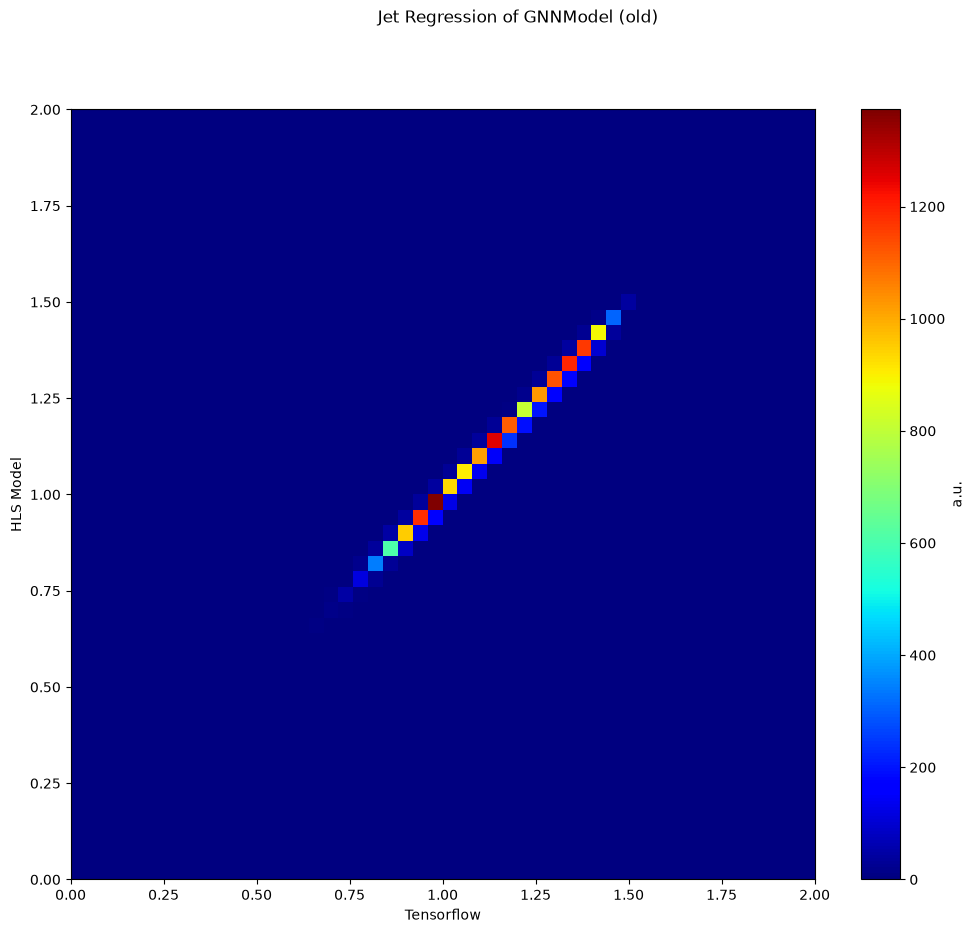

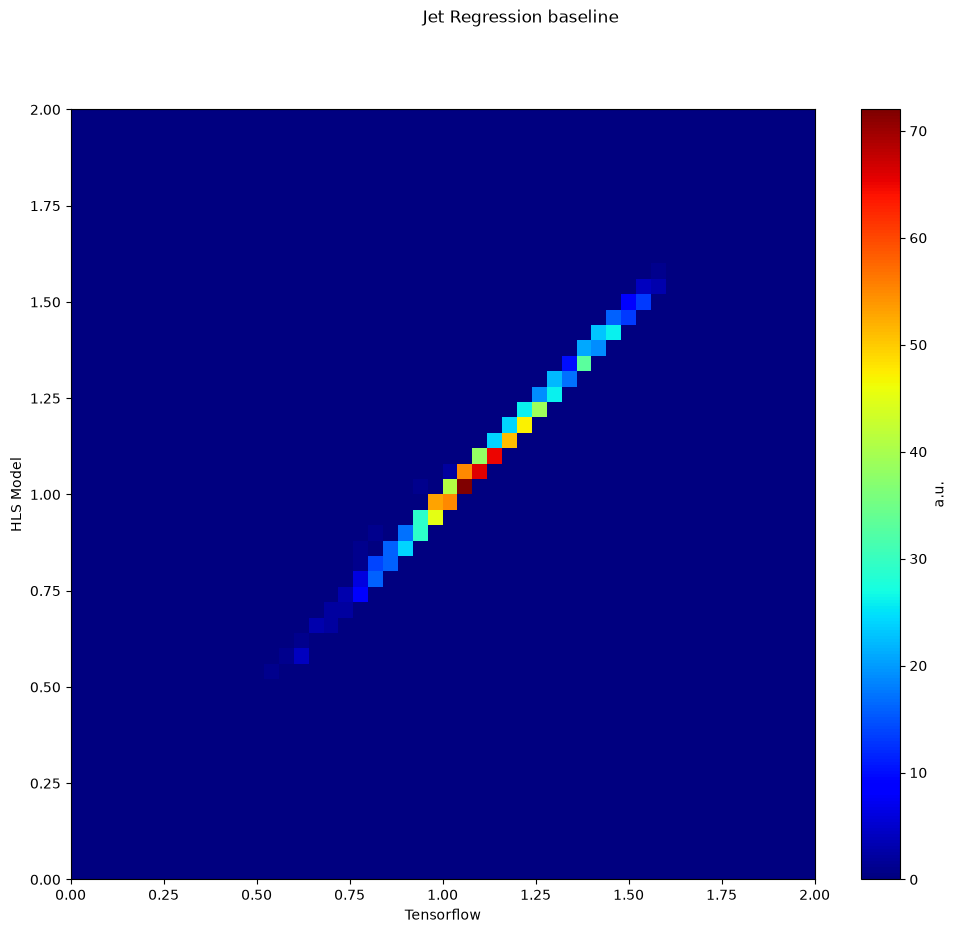

In [20]:
# Regression plots
figure = plot_2d(
    y_ptreg_old[:, 0],
    # cmssw_scores['jet_SC4NGJet_score_regression'],
    y_ptreg_hls_old[:, 0],
    (0, 2), (0, 2),
    "Tensorflow", "HLS Model", "Jet Regression of GNNModel (old) "
)

# Regression plots baseline
figure = plot_2d(
    y_ptreg_baseline[:, 0],
    y_ptreg_hls_baseline[:, 0],
    (0, 2), (0, 2),
    "Tensorflow", "HLS Model", "Jet Regression baseline"
)

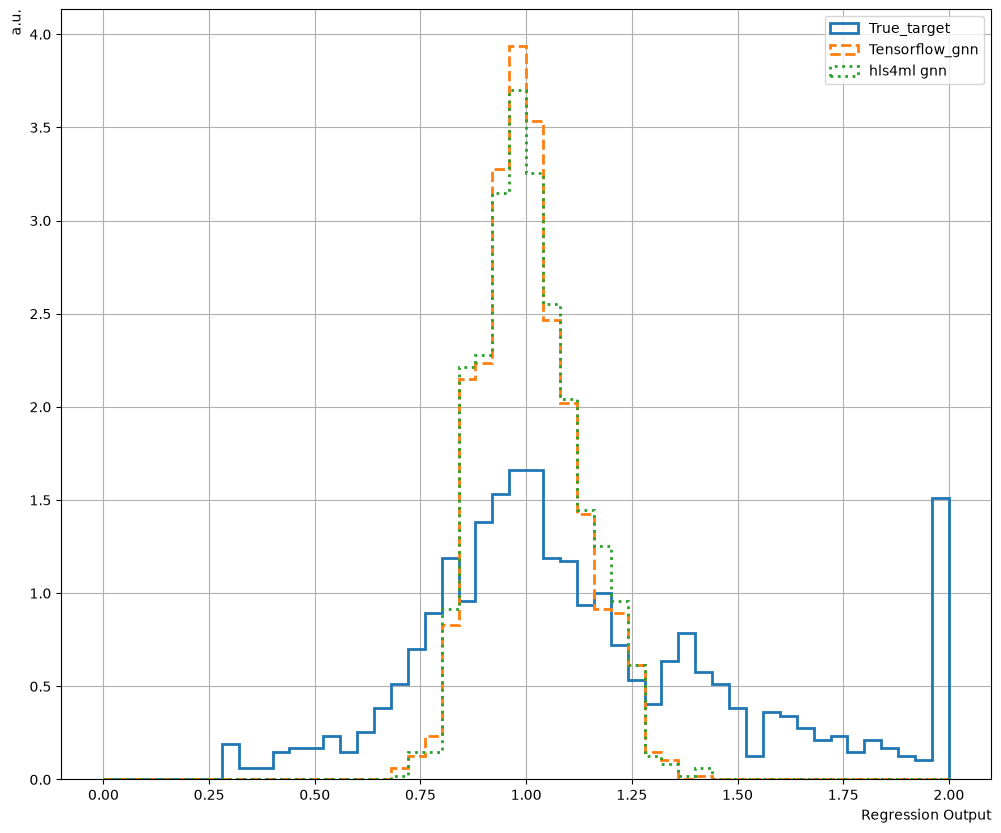

Bit accuracy (regression): 0.00%
Bit accuracy (regression): 0.01%


<Figure size 640x480 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

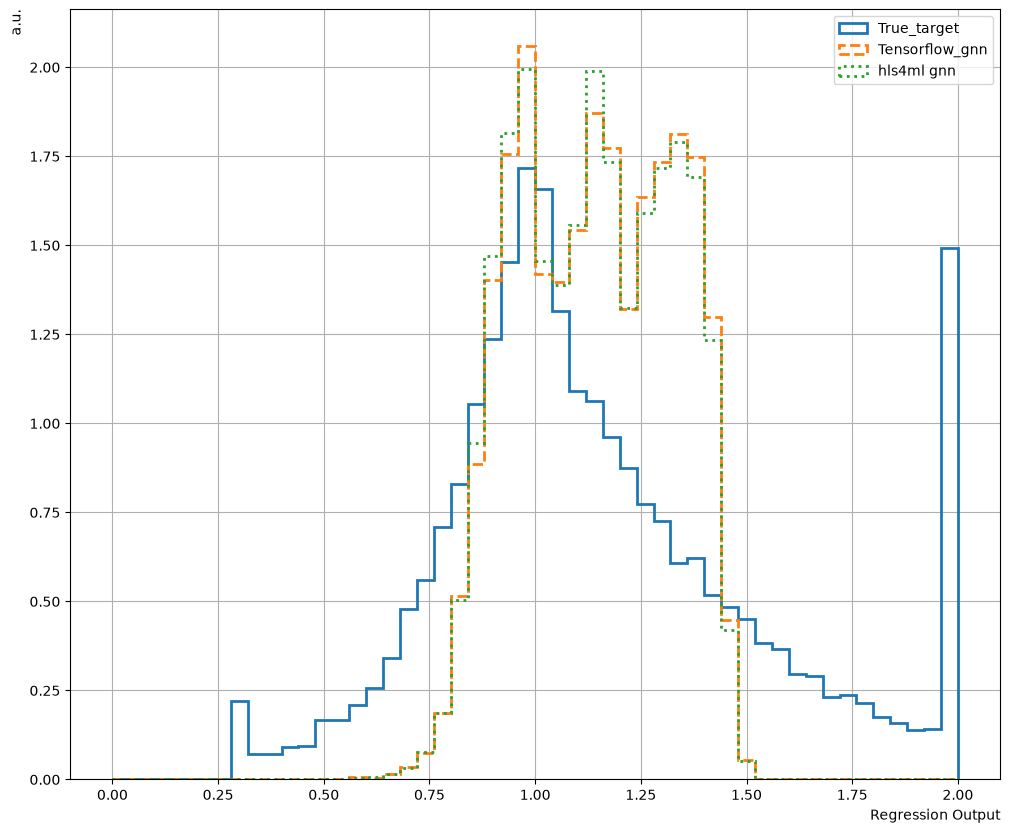

In [21]:
figure = plot_histo(
    [pt_target,                                       # Ground truth target
     y_ptreg[:, 0],
    #  cmssw_scores['jet_SC4NGJet_score_regression'],
     y_ptreg_hls[:, 0]],
    ["True_target","Tensorflow_gnn", #"CMSSW Emulation gnn", 
     "hls4ml gnn"], #"Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)
display(figure)

figure = plot_histo(
    [pt_target_test_old,                                       # Ground truth target
     y_ptreg_old[:, 0],
    #  cmssw_scores['jet_SC4NGJet_score_regression'],
     y_ptreg_hls_old[:, 0]],
    ["True_target","Tensorflow_gnn", #"CMSSW Emulation gnn", 
     "hls4ml gnn"], #"Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)

bit_accurate = np.count_nonzero(
    y_ptreg[:, 0] - y_ptreg_hls[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_test):.2f}%")

bit_accurate = np.count_nonzero(
    y_ptreg_old[:, 0] - y_ptreg_hls_old[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_test_old):.2f}%")

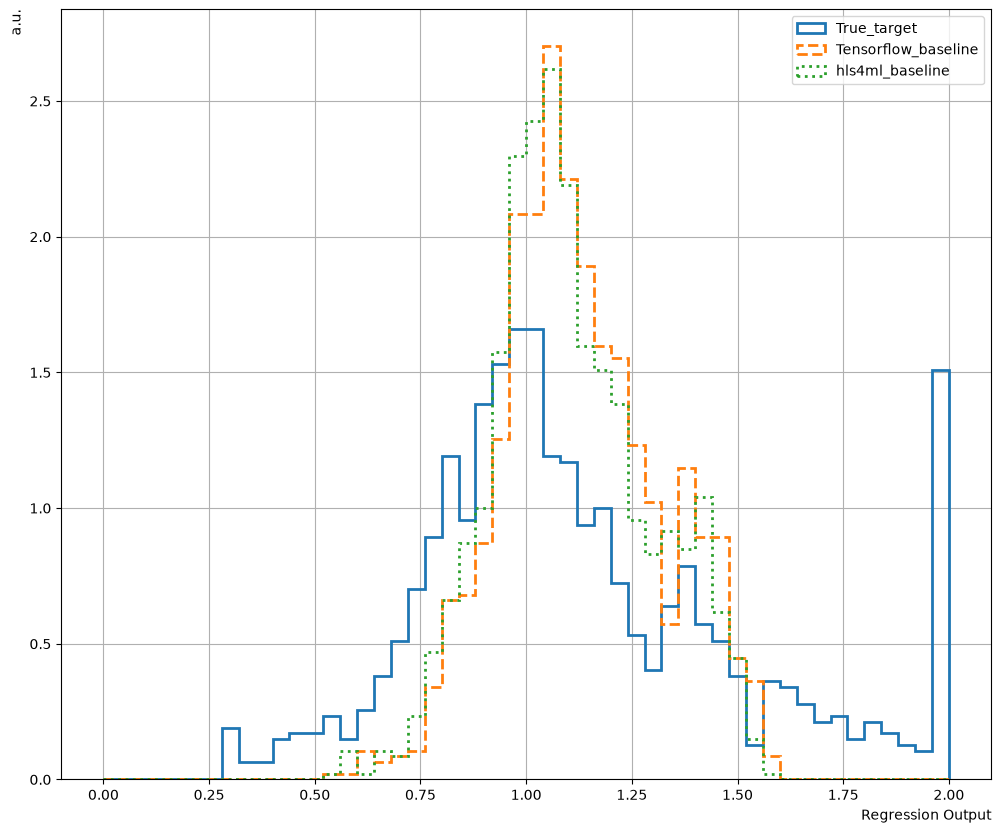

Bit accuracy (regression): 0.00%
Bit accuracy (regression): 0.00%


<Figure size 640x480 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

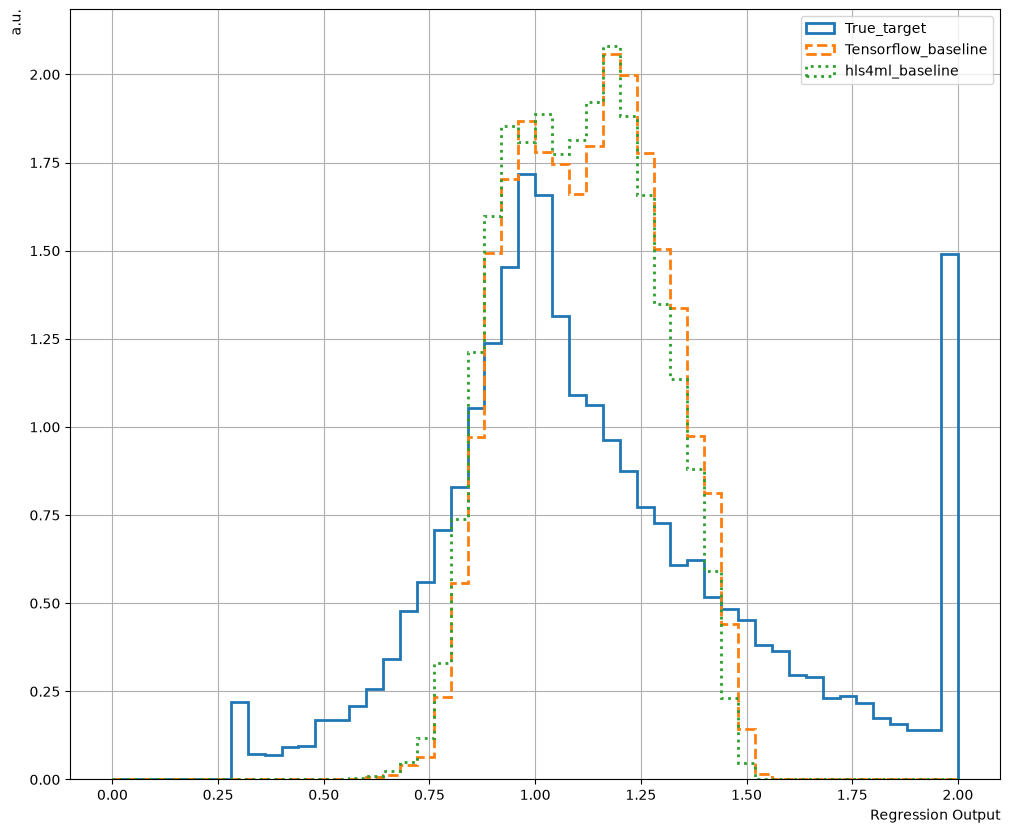

In [22]:
figure = plot_histo(
    [pt_target,                                       # Ground truth target
    #  y_ptreg[:, 0],
    # #  cmssw_scores['jet_SC4NGJet_score_regression'],
    #  y_ptreg_hls[:, 0],
     y_ptreg_baseline[:, 0],
     y_ptreg_hls_baseline[:, 0]],
    ["True_target","Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)
display(figure)

figure = plot_histo(
    [pt_target_test_old,                                       # Ground truth target
     y_ptreg_baseline_old[:, 0],
    #  cmssw_scores['jet_SC4NGJet_score_regression'],
     y_ptreg_hls_baseline_old[:, 0]],
    ["True_target","Tensorflow_baseline", #"CMSSW Emulation gnn", 
     "hls4ml_baseline"], #"Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)

bit_accurate = np.count_nonzero(
    y_ptreg_baseline[:, 0] - y_ptreg_hls_baseline[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_test):.2f}%")

bit_accurate = np.count_nonzero(
    y_ptreg_baseline_old[:, 0] - y_ptreg_hls_baseline_old[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_test_old):.2f}%")

<Figure size 640x480 with 0 Axes>

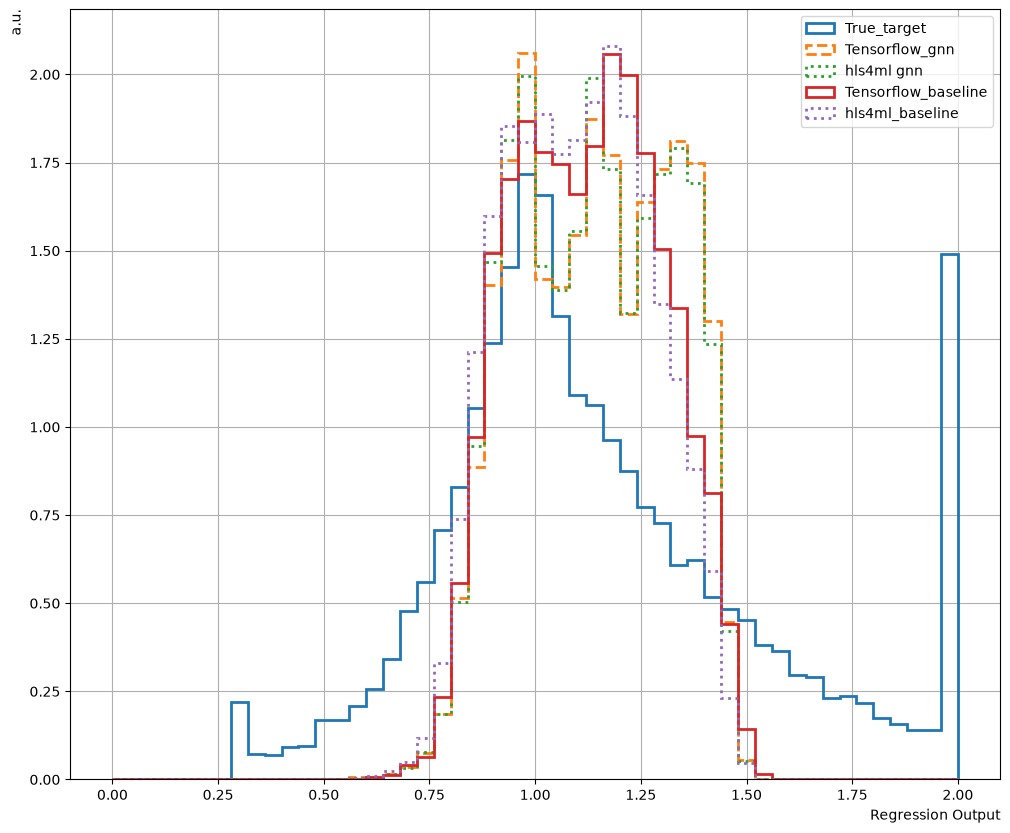

In [23]:
# figure = plot_histo(
#     [pt_target,                                       # Ground truth target
#      y_ptreg[:, 0],
#     #  cmssw_scores['jet_SC4NGJet_score_regression'],
#      y_ptreg_hls[:, 0],
#      y_ptreg_baseline[:, 0],
#      y_ptreg_hls_baseline[:, 0]],
#     ["True_target","Tensorflow_gnn", # "CMSSW Emulation gnn", 
#      "hls4ml gnn", "Tensorflow_baseline", "hls4ml_baseline"],
#     "", 'Regression Output', 'a.u.', range=(0, 2)
# )
# display(figure)

figure = plot_histo(
    [pt_target_test_old,                                       # Ground truth target
     y_ptreg_old[:, 0],
     y_ptreg_hls_old[:, 0],
    #  cmssw_scores['jet_SC4NGJet_score_regression'],
    y_ptreg_baseline_old[:, 0],
     y_ptreg_hls_baseline_old[:, 0]],
    ["True_target","Tensorflow_gnn", # "CMSSW Emulation gnn", 
     "hls4ml gnn", "Tensorflow_baseline", "hls4ml_baseline"], #"Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)


In [24]:
def classwise_metrics(y_true_onehot, y_score, labels, model_name):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_score, axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))

    print(f"\n--- {model_name} ---")
    print(f"{'Class':<15}{'Recall (per-class acc)':<25}{'OvR accuracy':<15}{'Support'}")
    for i, label in enumerate(labels):
        support = cm[i].sum()
        recall_i = cm[i, i] / support if support > 0 else np.nan

        # one-vs-rest accuracy: positive = class i, negative = everything else
        y_true_bin = (y_true == i).astype(int)
        y_pred_bin = (y_pred == i).astype(int)
        ovr_acc = accuracy_score(y_true_bin, y_pred_bin)

        print(f"{label:<15}{recall_i:<25.4f}{ovr_acc:<15.4f}{support}")

    overall_acc = accuracy_score(y_true, y_pred)
    print(f"Overall accuracy: {overall_acc:.4f}")

    return cm

cm_gnn_tf   = classwise_metrics(Y_test_old, y_class_old,          labels, "GNN (TensorFlow)")
cm_gnn_hls  = classwise_metrics(Y_test_old, y_class_hls_old,       labels, "GNN (hls4ml)")
cm_base_tf  = classwise_metrics(Y_test_old, y_class_baseline_old, labels, "DeepSet Baseline (TensorFlow)")
cm_base_hls = classwise_metrics(Y_test_old, y_class_hls_baseline_old, labels, "DeepSet Baseline (hls4ml)")
print(Y_test_old.shape)


--- GNN (TensorFlow) ---
Class          Recall (per-class acc)   OvR accuracy   Support
b              0.4644                   0.7206         7477
charm          0.1032                   0.9250         349
light          0.3266                   0.8671         992
gluon          0.4488                   0.7917         3670
taup           0.6469                   0.9123         2280
taum           0.5828                   0.9094         2457
muon           0.9606                   0.9845         989
electron       0.7854                   0.9434         1016
Overall accuracy: 0.5270

--- GNN (hls4ml) ---
Class          Recall (per-class acc)   OvR accuracy   Support
b              0.5261                   0.7279         7477
charm          0.0802                   0.9247         349
light          0.3216                   0.8626         992
gluon          0.3738                   0.7993         3670
taup           0.6504                   0.9128         2280
taum           0.5836     

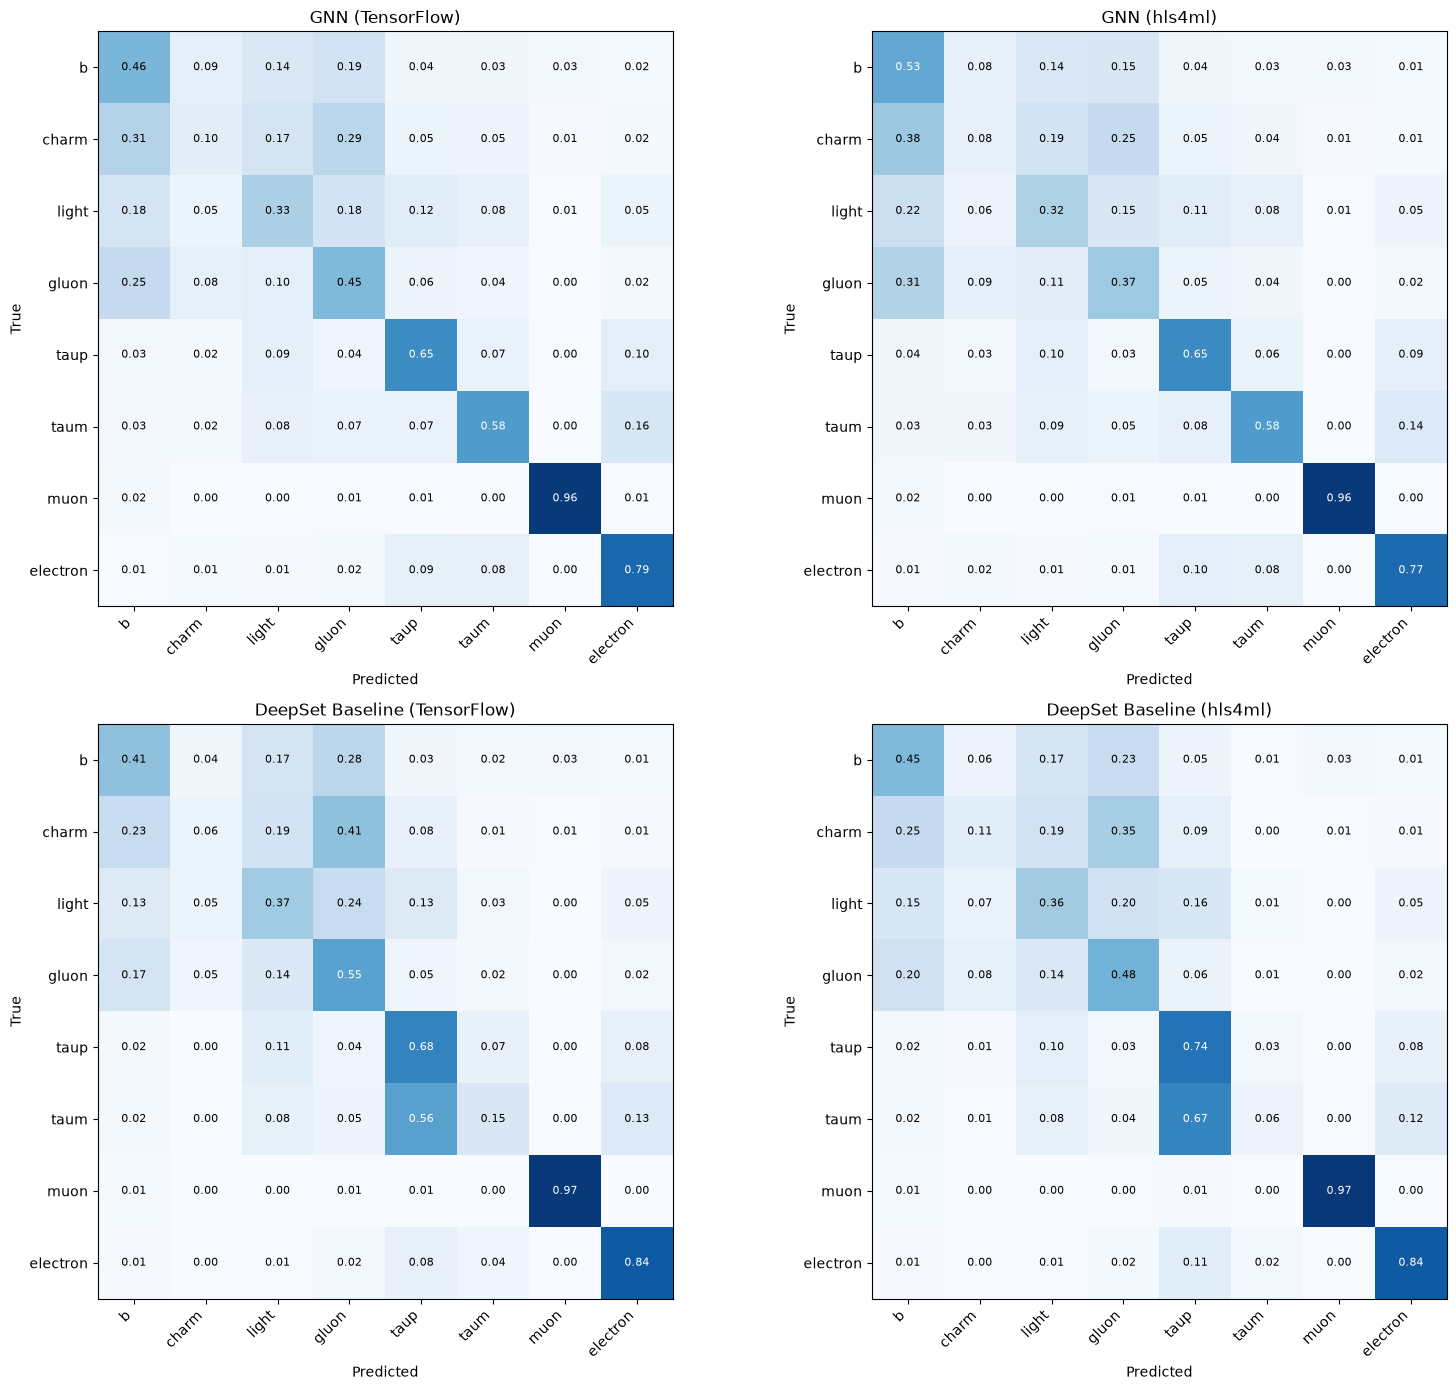

In [25]:
def plot_confusion_matrix(y_true_onehot, y_score, labels, title, ax):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_score, axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize (recall per row)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

    # annotate each cell with the fraction
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cm_norm[i, j]
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)

    return im

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

plot_confusion_matrix(Y_test_old, y_class_old,             labels, 'GNN (TensorFlow)',            axes[0,0])
plot_confusion_matrix(Y_test_old, y_class_hls_old,         labels, 'GNN (hls4ml)',                axes[0,1])
plot_confusion_matrix(Y_test_old, y_class_baseline_old,    labels, 'DeepSet Baseline (TensorFlow)', axes[1,0])
plot_confusion_matrix(Y_test_old, y_class_hls_baseline_old, labels, 'DeepSet Baseline (hls4ml)',    axes[1,1])

plt.tight_layout()
plt.show()

In [26]:
cm_gnn_tf   = classwise_metrics(Y_test, y_class,          labels, "GNN (TensorFlow)")
cm_gnn_hls  = classwise_metrics(Y_test, y_hls,       labels, "GNN (hls4ml)")
cm_base_tf  = classwise_metrics(Y_test, y_class_baseline, labels, "DeepSet Baseline (TensorFlow)")
cm_base_hls = classwise_metrics(Y_test, y_hls_baseline, labels, "DeepSet Baseline (hls4ml)")
print(Y_test.shape)


--- GNN (TensorFlow) ---
Class          Recall (per-class acc)   OvR accuracy   Support
b              0.0323                   0.6162         465
charm          0.0000                   0.9779         22
light          0.2222                   0.7277         63
gluon          0.0102                   0.8272         197
taup           0.3617                   0.8085         141
taum           0.5610                   0.6902         164
muon           0.8871                   0.9762         62
electron       0.8689                   0.8562         61
Overall accuracy: 0.2400

--- GNN (hls4ml) ---
Class          Recall (per-class acc)   OvR accuracy   Support
b              0.0387                   0.6187         465
charm          0.0455                   0.9711         22
light          0.2381                   0.7115         63
gluon          0.0051                   0.8298         197
taup           0.3972                   0.8153         141
taum           0.5427                   

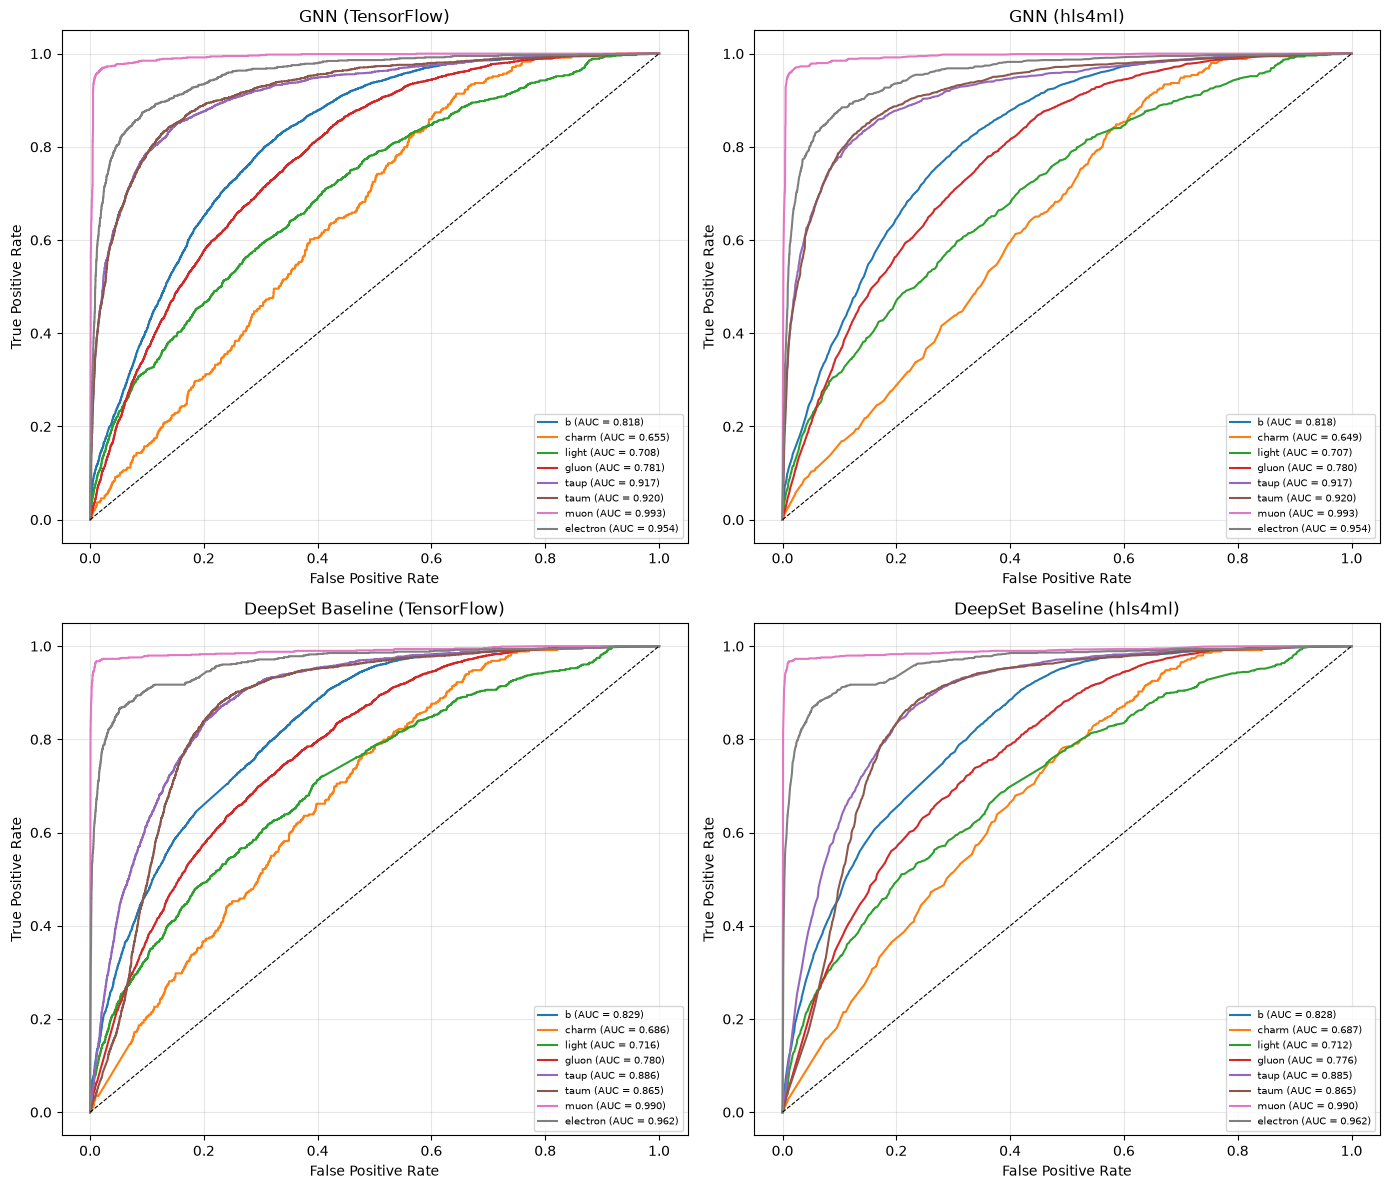

In [27]:
def plot_roc_ovr(y_true_onehot, y_score, labels, title, ax):
    for i, label in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_roc_ovr(Y_test_old, y_class_old,              labels, 'GNN (TensorFlow)',             axes[0,0])
plot_roc_ovr(Y_test_old, y_class_hls_old,          labels, 'GNN (hls4ml)',                 axes[0,1])
plot_roc_ovr(Y_test_old, y_class_baseline_old,     labels, 'DeepSet Baseline (TensorFlow)', axes[1,0])
plot_roc_ovr(Y_test_old, y_class_hls_baseline_old, labels, 'DeepSet Baseline (hls4ml)',     axes[1,1])

plt.tight_layout()
plt.show()

In [28]:
def macro_auc(y_true_onehot, y_score, labels):
    aucs = {}
    for i, label in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_score[:, i])
        aucs[label] = auc(fpr, tpr)
    aucs['macro_avg'] = np.mean(list(aucs.values()))
    return aucs

for name, y_score in [('GNN TF', y_class_old), ('GNN hls4ml', y_class_hls_old),
                       ('Baseline TF', y_class_baseline_old), ('Baseline hls4ml', y_class_hls_baseline_old)]:
    aucs = macro_auc(Y_test_old, y_score, labels)
    print(f"\n{name}:")
    for label, val in aucs.items():
        print(f"  {label:<12}{val:.4f}")


GNN TF:
  b           0.8181
  charm       0.6548
  light       0.7085
  gluon       0.7806
  taup        0.9171
  taum        0.9202
  muon        0.9935
  electron    0.9543
  macro_avg   0.8434

GNN hls4ml:
  b           0.8177
  charm       0.6494
  light       0.7071
  gluon       0.7800
  taup        0.9165
  taum        0.9202
  muon        0.9935
  electron    0.9543
  macro_avg   0.8423

Baseline TF:
  b           0.8291
  charm       0.6864
  light       0.7157
  gluon       0.7797
  taup        0.8855
  taum        0.8653
  muon        0.9896
  electron    0.9621
  macro_avg   0.8392

Baseline hls4ml:
  b           0.8279
  charm       0.6875
  light       0.7120
  gluon       0.7755
  taup        0.8854
  taum        0.8645
  muon        0.9896
  electron    0.9622
  macro_avg   0.8381
